# Full paper analysis

This notebook reproduces every figure and statistic for the paper
"Machine Learning for Health in Africa: A Scientometric Analysis of
African-Affiliated Research (2023–2025)".

It contains the same analysis as `analyses/00_full_paper_analysis.py`,
split into one cell per analysis section so the intermediate results can
be inspected step by step.

**Corpus.** `data/included_papers.csv` — every paper with an include
decision in both manual review rounds (1,158 papers, 2023–2025).

**Outputs.** `figures/*.png|.pdf` (one file per manuscript figure),
`figures/stats.json` (every scalar / small table the manuscript text
cites), and `figures/tables/*.csv` (machine-readable manuscript tables).

The LLM-extracted dataset / modality / patient-origin fields produced by
notebook 05 are reused from the cache CSV (no LLM call is made here), and
author seniority is enriched from OpenAlex with results cached in
`data/openalex_author_cache.json`.

## Imports and configuration

In [1]:
%matplotlib inline
from __future__ import annotations

import json
import os
import re
import sys
import time
from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd

try:
    import networkx as nx
except ImportError:  # pragma: no cover
    print("networkx is required: pip install networkx", file=sys.stderr)
    raise

# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #
# repo root (the notebook lives in analyses/)
HERE = Path.cwd()
ROOT = HERE.parent if HERE.name == "analyses" else HERE
DATA = ROOT / "data"
FIG = ROOT / "figures"
TABLES = FIG / "tables"
FIG.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)

DATA_PATH = DATA / "included_papers.csv"
LLM_CACHE_PATH = DATA / "Papers_step_05_dataset_landscape_llm_cache.csv"
OPENALEX_CACHE = DATA / "openalex_author_cache.json"

ENABLE_OPENALEX = True  # set False to skip the (cached) OpenAlex enrichment
OPENALEX_TOP_AUTHORS = 60  # number of top African-corpus authors to enrich
OPENALEX_MAILTO = "liss@pads.rwth-aachen.de"  # polite pool

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.autolayout": False,
    }
)

## African country list and region grouping

In [2]:
AFRICAN_COUNTRIES = {
    "Algeria",
    "Angola",
    "Benin",
    "Botswana",
    "Burkina Faso",
    "Burundi",
    "Cabo Verde",
    "Cameroon",
    "Central African Republic",
    "Chad",
    "Comoros",
    "Congo",
    "Democratic Republic of the Congo",
    "Cote d'Ivoire",
    "Djibouti",
    "Egypt",
    "Equatorial Guinea",
    "Eritrea",
    "Eswatini",
    "Ethiopia",
    "Gabon",
    "Gambia",
    "Ghana",
    "Guinea",
    "Guinea-Bissau",
    "Kenya",
    "Lesotho",
    "Liberia",
    "Libya",
    "Madagascar",
    "Malawi",
    "Mali",
    "Mauritania",
    "Mauritius",
    "Morocco",
    "Mozambique",
    "Namibia",
    "Niger",
    "Nigeria",
    "Rwanda",
    "Sao Tome and Principe",
    "Senegal",
    "Seychelles",
    "Sierra Leone",
    "Somalia",
    "South Africa",
    "South Sudan",
    "Sudan",
    "Tanzania",
    "Togo",
    "Tunisia",
    "Uganda",
    "Zambia",
    "Zimbabwe",
}

# Region grouping for African countries (UN sub-regions, simplified)
AFRICAN_REGION = {
    # North
    "Algeria": "North",
    "Egypt": "North",
    "Libya": "North",
    "Morocco": "North",
    "Sudan": "North",
    "Tunisia": "North",
    # West
    "Benin": "West",
    "Burkina Faso": "West",
    "Cabo Verde": "West",
    "Cote d'Ivoire": "West",
    "Gambia": "West",
    "Ghana": "West",
    "Guinea": "West",
    "Guinea-Bissau": "West",
    "Liberia": "West",
    "Mali": "West",
    "Mauritania": "West",
    "Niger": "West",
    "Nigeria": "West",
    "Senegal": "West",
    "Sierra Leone": "West",
    "Togo": "West",
    # East
    "Burundi": "East",
    "Comoros": "East",
    "Djibouti": "East",
    "Eritrea": "East",
    "Ethiopia": "East",
    "Kenya": "East",
    "Madagascar": "East",
    "Malawi": "East",
    "Mauritius": "East",
    "Mozambique": "East",
    "Rwanda": "East",
    "Seychelles": "East",
    "Somalia": "East",
    "South Sudan": "East",
    "Tanzania": "East",
    "Uganda": "East",
    "Zambia": "East",
    "Zimbabwe": "East",
    # Central
    "Cameroon": "Central",
    "Central African Republic": "Central",
    "Chad": "Central",
    "Congo": "Central",
    "Democratic Republic of the Congo": "Central",
    "Equatorial Guinea": "Central",
    "Gabon": "Central",
    "Sao Tome and Principe": "Central",
    # Southern
    "Botswana": "Southern",
    "Eswatini": "Southern",
    "Lesotho": "Southern",
    "Namibia": "Southern",
    "South Africa": "Southern",
}

STATS: dict = {}  # collected numbers for the manuscript

## Helper functions

`save_fig` additionally shows each figure inline in the notebook.

In [3]:
# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #
def split_multi(val, sep=";"):
    if pd.isna(val):
        return []
    return [x.strip() for x in str(val).split(sep) if x.strip()]


def save_fig(fig, name, caption=""):
    """Save a figure as both PNG (for the docx) and PDF (for submission),
    and show it inline in the notebook."""
    png = FIG / f"{name}.png"
    pdf = FIG / f"{name}.pdf"
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"  saved {png.name}  {('— ' + caption) if caption else ''}")


def save_table(df_, name):
    path = TABLES / f"{name}.csv"
    df_.to_csv(path)
    print(f"  saved table {path.name}")


def is_african(country):
    return country in AFRICAN_COUNTRIES


def parse_affiliations(aff_str):
    """Parse the `Authors Affiliations` field.

    Format: "Surname, Given (Inst A; Inst B); Next Author (Inst C); ..."
    Returns a list of (author_name, [institutions]) preserving author order.
    """
    if pd.isna(aff_str):
        return []
    s = str(aff_str)
    out = []
    # Split author records at "); " boundaries while keeping the trailing ")".
    # An author record looks like  NAME (INST1; INST2)
    # Authors are separated by "); " — but institution lists also use "; ".
    # Use a regex that matches  <name up to '('> ( <stuff no nested parens> )
    for m in re.finditer(r"([^()]+?)\s*\(([^()]*)\)", s):
        name = m.group(1).strip().lstrip(";").strip()
        insts = [i.strip() for i in m.group(2).split(";") if i.strip()]
        if name:
            out.append((name, insts))
    return out


def country_of_institution_map(df):
    """Build institution -> country lookup from the aligned org/country lists."""
    m = {}
    for _, r in df.iterrows():
        for org, ctry in zip(r["org_list"], r["country_list"]):
            m.setdefault(org, ctry)
    return m

## Load the corpus

`data/included_papers.csv` already contains exactly the corpus (papers
included in both review rounds), so no further filtering is needed.

In [4]:
# --------------------------------------------------------------------------- #
# Load corpus
# --------------------------------------------------------------------------- #
def load_corpus():
    # data/included_papers.csv already contains exactly the corpus: every paper
    # with an include decision in both manual review rounds (see
    # prepare_review_data.py), so no further filtering is needed.
    df = pd.read_csv(DATA_PATH, low_memory=False)
    df.reset_index(drop=True, inplace=True)

    # Merge LLM-extracted dataset / modality fields if present.
    if LLM_CACHE_PATH.exists():
        cache = pd.read_csv(LLM_CACHE_PATH, low_memory=False).drop_duplicates(
            "Paper_ID", keep="last"
        )
        df = df.merge(cache, on="Paper_ID", how="left")

    # Normalise a few derived columns once.
    df["n_authors"] = df["Authors"].apply(lambda v: len(split_multi(v)))
    df["org_list"] = df["Research Organizations - standardized"].apply(split_multi)
    df["country_list"] = df["Country of standardized research organization"].apply(
        split_multi
    )
    df["country_set"] = df["country_list"].apply(set)
    df["affil_parsed"] = df["Authors Affiliations"].apply(parse_affiliations)
    df["Times cited"] = pd.to_numeric(df["Times cited"], errors="coerce")
    df["FCR"] = pd.to_numeric(df["FCR"], errors="coerce")
    df["PubYear"] = pd.to_numeric(df["PubYear"], errors="coerce").astype("Int64")
    return df


print(f"Loading corpus from {DATA_PATH.relative_to(ROOT)} …")
df = load_corpus()
print(f"Corpus: {len(df)} papers, {df['PubYear'].min()}–{df['PubYear'].max()}")

Loading corpus from data/included_papers.csv …
Corpus: 1158 papers, 2023–2025


## 1. Descriptive overview


[1] Descriptive overview


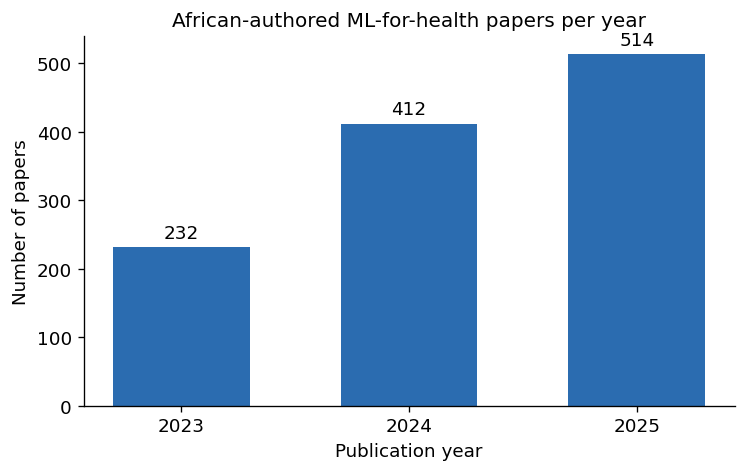

  saved fig01_papers_per_year.png  — publications per year


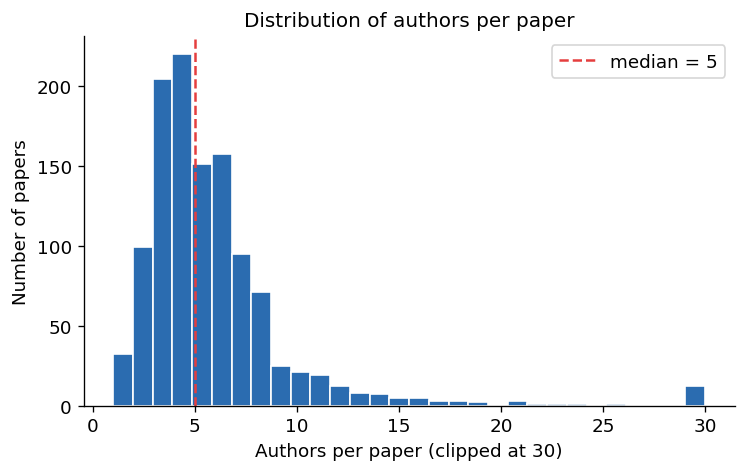

  saved fig02_authors_per_paper.png  — authors per paper


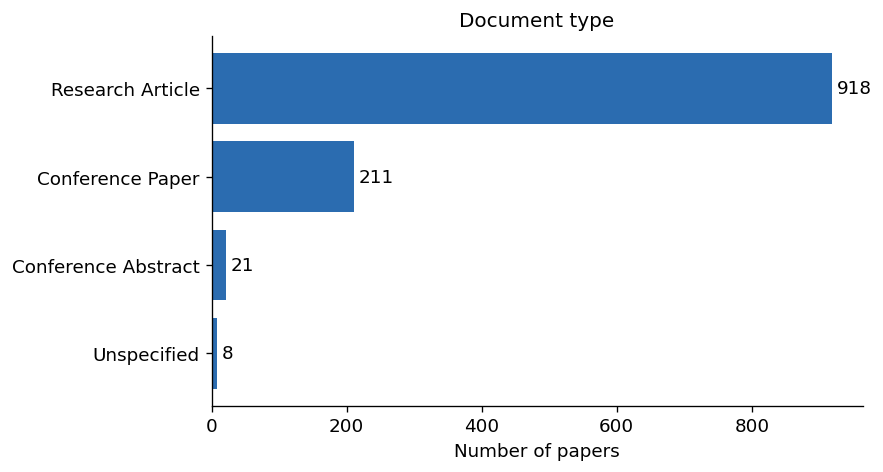

  saved fig03_document_type.png  — document types
  saved table top_journals.csv


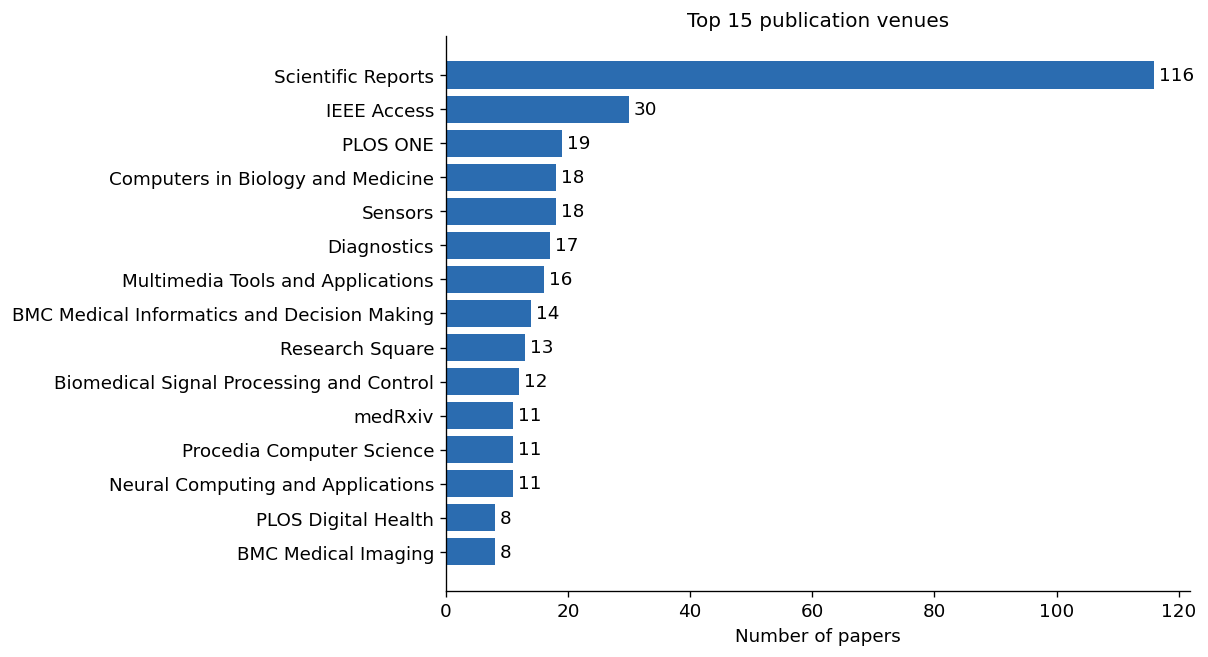

  saved fig04_top_journals.png  — top journals
  saved table top_publishers.csv


In [5]:
# --------------------------------------------------------------------------- #
# 1. Descriptive overview
# --------------------------------------------------------------------------- #
def analysis_descriptive(df):
    print("\n[1] Descriptive overview")
    STATS["n_papers"] = int(len(df))
    STATS["year_min"] = int(df["PubYear"].min())
    STATS["year_max"] = int(df["PubYear"].max())

    year_counts = df["PubYear"].value_counts().sort_index()
    STATS["papers_per_year"] = {int(y): int(n) for y, n in year_counts.items()}
    # Year-over-year growth
    yrs = sorted(STATS["papers_per_year"])
    STATS["growth_2023_2025_pct"] = round(
        100
        * (STATS["papers_per_year"][yrs[-1]] / STATS["papers_per_year"][yrs[0]] - 1),
        1,
    )

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(
        [str(y) for y in year_counts.index],
        year_counts.values,
        color="#2b6cb0",
        width=0.6,
    )
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Publication year")
    ax.set_ylabel("Number of papers")
    ax.set_title("African-authored ML-for-health papers per year")
    save_fig(fig, "fig01_papers_per_year", "publications per year")

    # Authorship
    ap = df["n_authors"]
    STATS["authors_per_paper"] = {
        "mean": round(float(ap.mean()), 2),
        "std": round(float(ap.std()), 2),
        "median": int(ap.median()),
        "min": int(ap.min()),
        "max": int(ap.max()),
    }
    top_auth_row = df.loc[ap.idxmax()]
    STATS["max_authors_paper_title"] = str(top_auth_row["Title"])

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(ap.clip(upper=30), bins=30, color="#2b6cb0", edgecolor="white")
    ax.axvline(
        ap.median(), color="#e53e3e", ls="--", label=f"median = {int(ap.median())}"
    )
    ax.set_xlabel("Authors per paper (clipped at 30)")
    ax.set_ylabel("Number of papers")
    ax.set_title("Distribution of authors per paper")
    ax.legend()
    save_fig(fig, "fig02_authors_per_paper", "authors per paper")

    # Document type
    dt = df["Document Type"].fillna("Unspecified").value_counts()
    STATS["document_types"] = {k: int(v) for k, v in dt.items()}
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.barh(dt.index[::-1], dt.values[::-1], color="#2b6cb0")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of papers")
    ax.set_title("Document type")
    save_fig(fig, "fig03_document_type", "document types")

    # Open access
    df["oa_simple"] = df["Open Access"].apply(
        lambda v: "Closed" if v == "Closed" else "Open access"
    )
    oa = df["oa_simple"].value_counts()
    STATS["open_access"] = {k: int(v) for k, v in oa.items()}
    STATS["open_access_share"] = round(
        float((df["oa_simple"] == "Open access").mean()), 3
    )
    # Detailed OA flavours
    oa_detail = Counter()
    for v in df["Open Access"]:
        if v == "Closed":
            oa_detail["Closed"] += 1
        else:
            for flavour in split_multi(v):
                if flavour != "All OA":
                    oa_detail[flavour] += 1
    STATS["open_access_detail"] = dict(oa_detail)

    # Top journals
    journals = df["Source title"].value_counts().head(20)
    STATS["top_journals"] = {k: int(v) for k, v in journals.head(15).items()}
    save_table(journals.rename("papers").to_frame(), "top_journals")
    fig, ax = plt.subplots(figsize=(8, 6))
    j = journals.head(15)
    bars = ax.barh([t[:45] for t in j.index[::-1]], j.values[::-1], color="#2b6cb0")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of papers")
    ax.set_title("Top 15 publication venues")
    save_fig(fig, "fig04_top_journals", "top journals")

    # Publishers
    if "Publisher" in df.columns:
        pubs = df["Publisher"].value_counts().head(15)
        STATS["top_publishers"] = {k: int(v) for k, v in pubs.head(10).items()}
        save_table(pubs.rename("papers").to_frame(), "top_publishers")
    return df


df = analysis_descriptive(df)

## 2. Geography of African research activity


[2] Geography (countries)
  saved table african_countries.csv
  saved table nonafrican_countries.csv


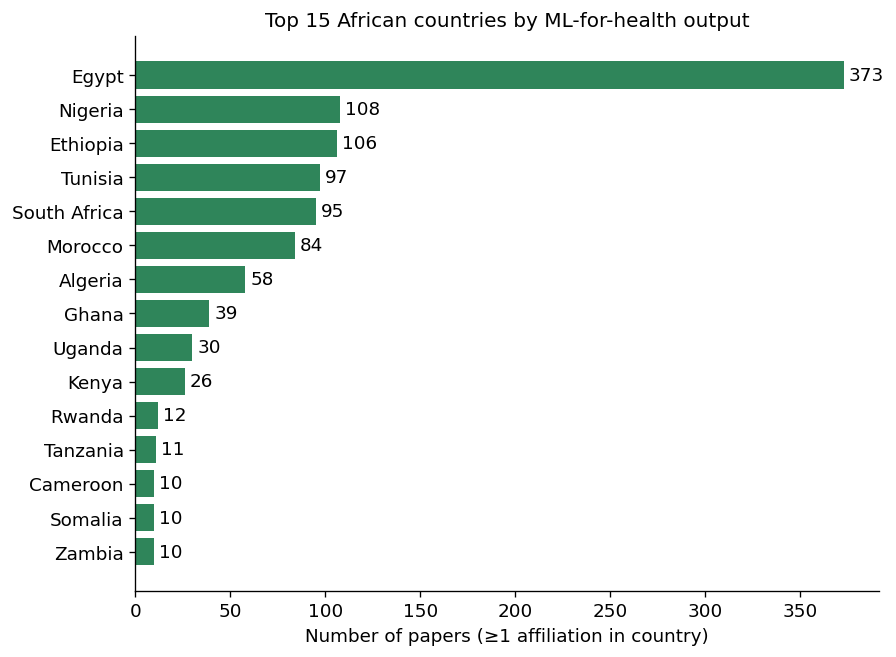

  saved fig05_top_african_countries.png  — top African countries


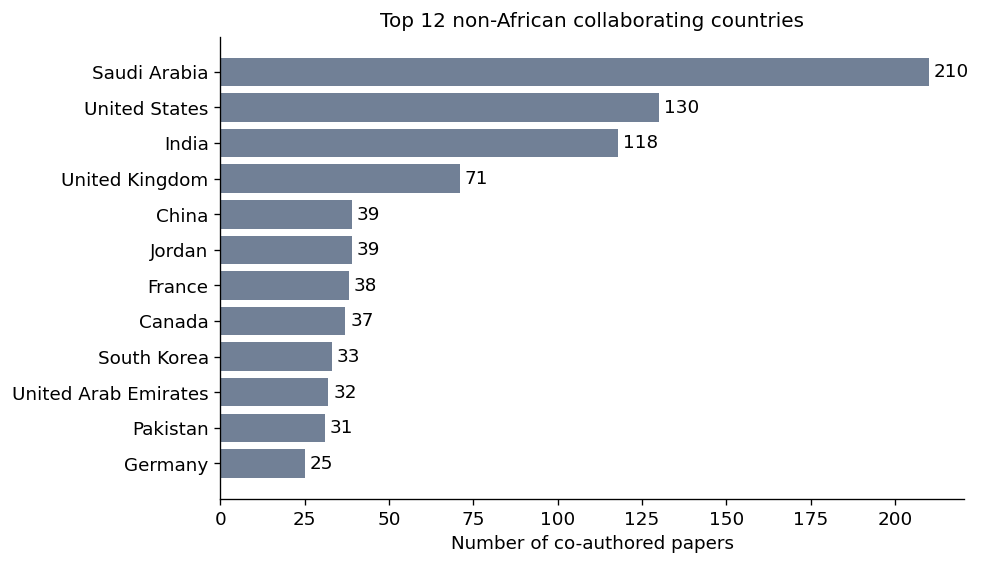

  saved fig06_top_nonafrican_countries.png  — top non-African countries


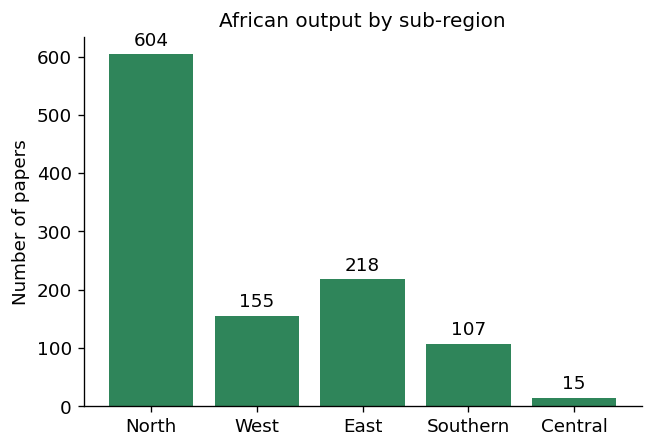

  saved fig07_african_regions.png  — regional breakdown


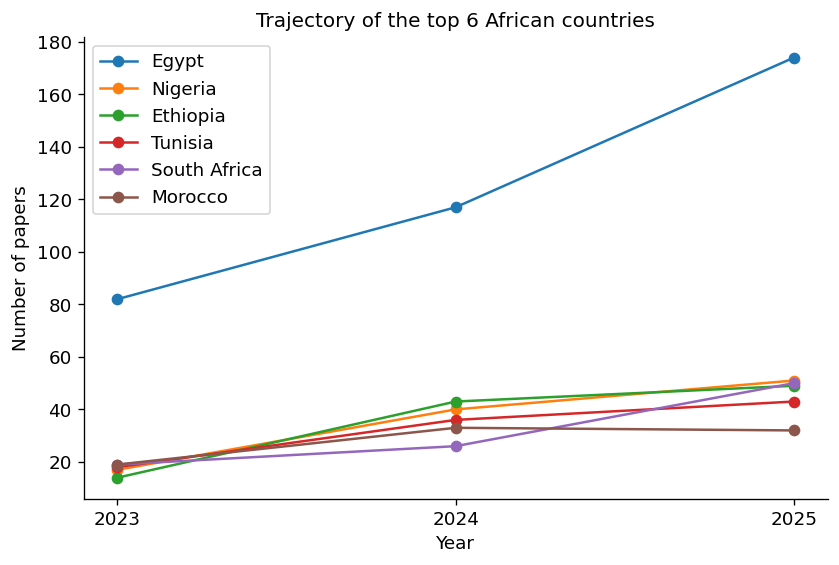

  saved fig08_country_trajectory.png  — country trajectory


In [6]:
# --------------------------------------------------------------------------- #
# 2. Geography of African research activity
# --------------------------------------------------------------------------- #
def analysis_geography(df):
    print("\n[2] Geography (countries)")
    cc = Counter()
    for s in df["country_set"]:
        cc.update(s)
    africa = pd.Series({k: v for k, v in cc.items() if is_african(k)}).sort_values(
        ascending=False
    )
    nonafrica = pd.Series(
        {k: v for k, v in cc.items() if not is_african(k)}
    ).sort_values(ascending=False)

    STATS["n_african_countries"] = int(len(africa))
    STATS["n_nonafrican_countries"] = int(len(nonafrica))
    STATS["top_african_countries"] = {k: int(v) for k, v in africa.head(15).items()}
    STATS["top_nonafrican_countries"] = {
        k: int(v) for k, v in nonafrica.head(12).items()
    }
    save_table(africa.rename("papers").to_frame(), "african_countries")
    save_table(nonafrica.rename("papers").to_frame(), "nonafrican_countries")

    fig, ax = plt.subplots(figsize=(8, 6))
    a = africa.head(15)
    bars = ax.barh(a.index[::-1], a.values[::-1], color="#2f855a")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of papers (≥1 affiliation in country)")
    ax.set_title("Top 15 African countries by ML-for-health output")
    save_fig(fig, "fig05_top_african_countries", "top African countries")

    fig, ax = plt.subplots(figsize=(8, 5))
    n = nonafrica.head(12)
    bars = ax.barh(n.index[::-1], n.values[::-1], color="#718096")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of co-authored papers")
    ax.set_title("Top 12 non-African collaborating countries")
    save_fig(fig, "fig06_top_nonafrican_countries", "top non-African countries")

    # Regional breakdown
    region_papers = Counter()
    for s in df["country_set"]:
        regions = {AFRICAN_REGION[c] for c in s if c in AFRICAN_REGION}
        for r in regions:
            region_papers[r] += 1
    STATS["african_region_papers"] = dict(region_papers)
    fig, ax = plt.subplots(figsize=(6, 4))
    order = ["North", "West", "East", "Southern", "Central"]
    vals = [region_papers.get(r, 0) for r in order]
    bars = ax.bar(order, vals, color="#2f855a")
    ax.bar_label(bars, padding=3)
    ax.set_ylabel("Number of papers")
    ax.set_title("African output by sub-region")
    save_fig(fig, "fig07_african_regions", "regional breakdown")

    # Per-year trajectory for the top 6 African countries
    top6 = list(africa.head(6).index)
    years = sorted(df["PubYear"].dropna().unique().tolist())
    traj = {c: [] for c in top6}
    for y in years:
        sub = df[df["PubYear"] == y]
        yc = Counter()
        for s in sub["country_set"]:
            yc.update(s)
        for c in top6:
            traj[c].append(yc.get(c, 0))
    fig, ax = plt.subplots(figsize=(8, 5))
    for c in top6:
        ax.plot([int(y) for y in years], traj[c], marker="o", label=c)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of papers")
    ax.set_xticks([int(y) for y in years])
    ax.set_title("Trajectory of the top 6 African countries")
    ax.legend()
    save_fig(fig, "fig08_country_trajectory", "country trajectory")
    return cc


country_counts = analysis_geography(df)

## 2b. Collaboration share (paper level)


[2b] Collaboration share (paper level)


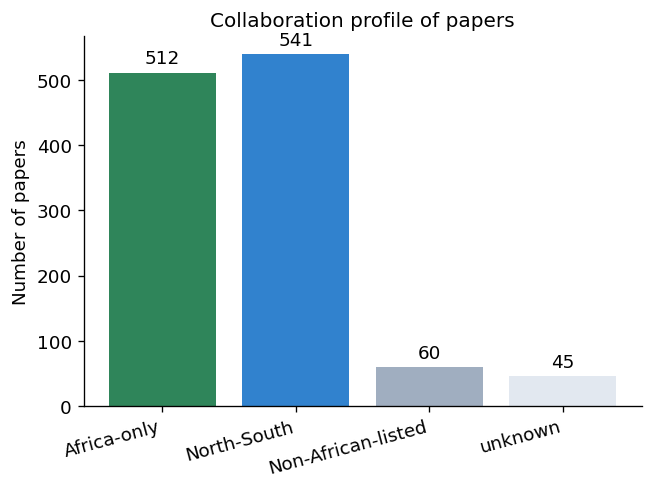

  saved fig09_collab_profile.png  — collaboration profile


In [7]:
def analysis_collab_share(df):
    """Per-paper North-South / South-South share, recovering African authorship
    from raw affiliations when the standardized country field misses it."""
    print("\n[2b] Collaboration share (paper level)")

    def raw_has_african(row):
        # fallback: scan raw affiliation text for African country names
        s = (
            str(row["Authors (Raw Affiliation)"])
            if "Authors (Raw Affiliation)" in row
            else ""
        )
        s2 = str(row["Authors Affiliations"])
        text = s + " " + s2
        return any(c in text for c in AFRICAN_COUNTRIES)

    def classify(row):
        cs = row["country_set"]
        if not cs:
            return "unknown"
        has_af = any(is_african(c) for c in cs)
        has_non = any(not is_african(c) for c in cs)
        if has_af and has_non:
            return "North-South"
        if has_af:
            return "Africa-only"
        # standardized field lists only non-African orgs — but corpus is
        # filtered for ≥1 African author, so treat as North-South collaboration.
        return "Non-African-listed"

    df["collab_type"] = df.apply(classify, axis=1)
    counts = df["collab_type"].value_counts()
    STATS["collab_type_counts"] = {k: int(v) for k, v in counts.items()}
    STATS["collab_type_share"] = {
        k: round(float(v), 3)
        for k, v in df["collab_type"].value_counts(normalize=True).items()
    }

    # Headline: international (any non-African co-affiliation) vs Africa-only
    intl = df["collab_type"].isin(["North-South", "Non-African-listed"]).mean()
    STATS["international_collab_share"] = round(float(intl), 3)
    STATS["africa_only_share"] = round(
        float((df["collab_type"] == "Africa-only").mean()), 3
    )

    fig, ax = plt.subplots(figsize=(6, 4))
    order = [
        t
        for t in ["Africa-only", "North-South", "Non-African-listed", "unknown"]
        if t in counts.index
    ]
    vals = [counts[t] for t in order]
    bars = ax.bar(
        order, vals, color=["#2f855a", "#3182ce", "#a0aec0", "#e2e8f0"][: len(order)]
    )
    ax.bar_label(bars, padding=3)
    ax.set_ylabel("Number of papers")
    ax.set_title("Collaboration profile of papers")
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
    save_fig(fig, "fig09_collab_profile", "collaboration profile")
    return df


df = analysis_collab_share(df)

## 3. Institutional capacities


[3] Institutional capacities
  saved table african_institutions.csv


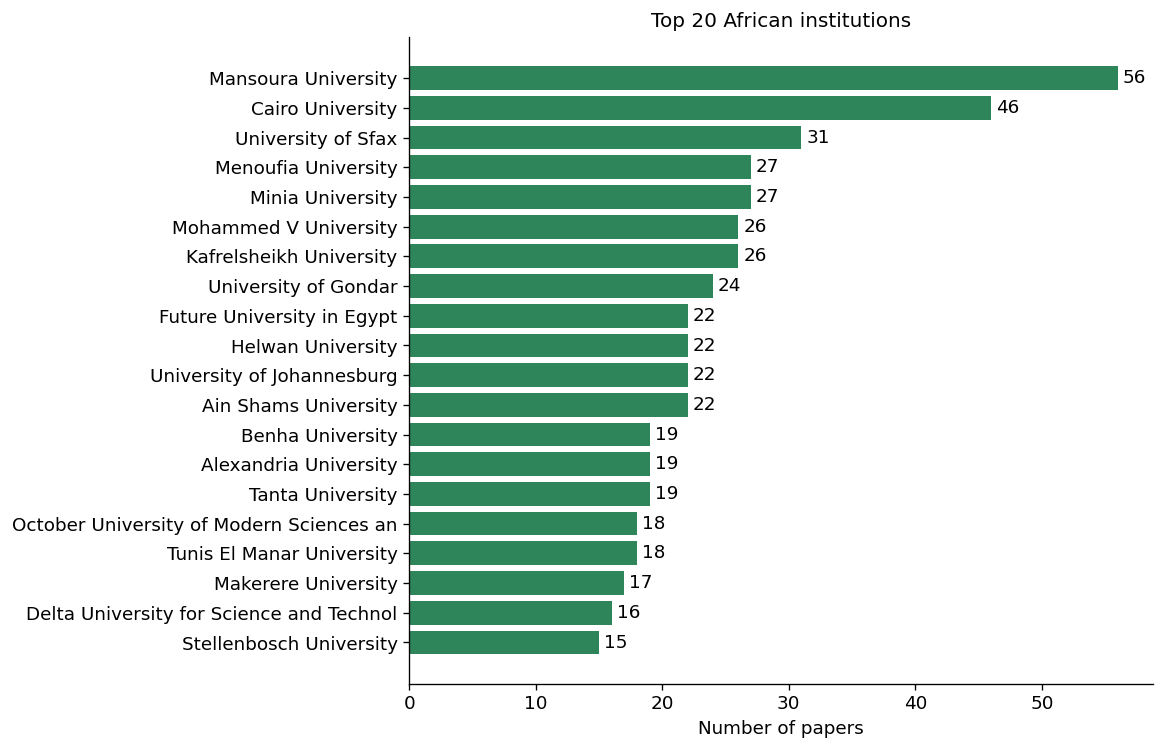

  saved fig10_top_institutions.png  — top institutions
  saved table institution_impact.csv
  saved table country_summary.csv


In [8]:
# --------------------------------------------------------------------------- #
# 3. Institutional capacities
# --------------------------------------------------------------------------- #
def analysis_institutions(df):
    print("\n[3] Institutional capacities")
    rows = []
    for _, r in df.iterrows():
        orgs = r["org_list"]
        ctrs = r["country_list"]
        for i, org in enumerate(orgs):
            country = ctrs[i] if i < len(ctrs) else None
            rows.append(
                {
                    "Paper_ID": r["Paper_ID"],
                    "PubYear": r["PubYear"],
                    "org": org,
                    "country": country,
                    "FCR": r["FCR"],
                    "Times cited": r["Times cited"],
                }
            )
    inst = pd.DataFrame(rows)
    inst["is_african"] = inst["country"].isin(AFRICAN_COUNTRIES)
    inst_u = inst.drop_duplicates(["Paper_ID", "org"])

    top_af = (
        inst_u[inst_u["is_african"]]
        .groupby("org")["Paper_ID"]
        .nunique()
        .sort_values(ascending=False)
    )
    STATS["top_african_institutions"] = {k: int(v) for k, v in top_af.head(20).items()}
    save_table(top_af.rename("papers").to_frame(), "african_institutions")

    fig, ax = plt.subplots(figsize=(8, 7))
    t = top_af.head(20)
    bars = ax.barh([x[:40] for x in t.index[::-1]], t.values[::-1], color="#2f855a")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of papers")
    ax.set_title("Top 20 African institutions")
    save_fig(fig, "fig10_top_institutions", "top institutions")

    # Impact (mean citations / FCR) of the top-20 institutions
    impact = (
        inst[inst["org"].isin(top_af.head(20).index)]
        .groupby("org")[["Times cited", "FCR"]]
        .mean()
        .round(2)
    )
    impact["papers"] = top_af.head(20)
    impact = impact.sort_values("FCR", ascending=False)
    STATS["institution_impact_top_fcr"] = {
        str(k): {
            "mean_FCR": float(v["FCR"]) if pd.notna(v["FCR"]) else None,
            "mean_citations": float(v["Times cited"])
            if pd.notna(v["Times cited"])
            else None,
            "papers": int(v["papers"]),
        }
        for k, v in impact.head(5).iterrows()
    }
    save_table(impact, "institution_impact")

    # Country-level summary table (papers, mean citations, mean FCR)
    country_summary = []
    for c in sorted({c for c in inst["country"].dropna() if is_african(c)}):
        sub_pids = inst_u[(inst_u["country"] == c)]["Paper_ID"].unique()
        sub = df[df["Paper_ID"].isin(sub_pids)]
        country_summary.append(
            {
                "country": c,
                "papers": len(sub),
                "mean_citations": round(float(sub["Times cited"].mean()), 2),
                "mean_FCR": round(float(sub["FCR"].mean()), 2)
                if sub["FCR"].notna().any()
                else None,
            }
        )
    cs_df = pd.DataFrame(country_summary).sort_values("papers", ascending=False)
    save_table(cs_df.set_index("country"), "country_summary")
    STATS["country_summary_top"] = cs_df.head(15).to_dict(orient="records")
    return inst, inst_u


inst, inst_u = analysis_institutions(df)

## 4. Collaboration networks


[4] Collaboration networks


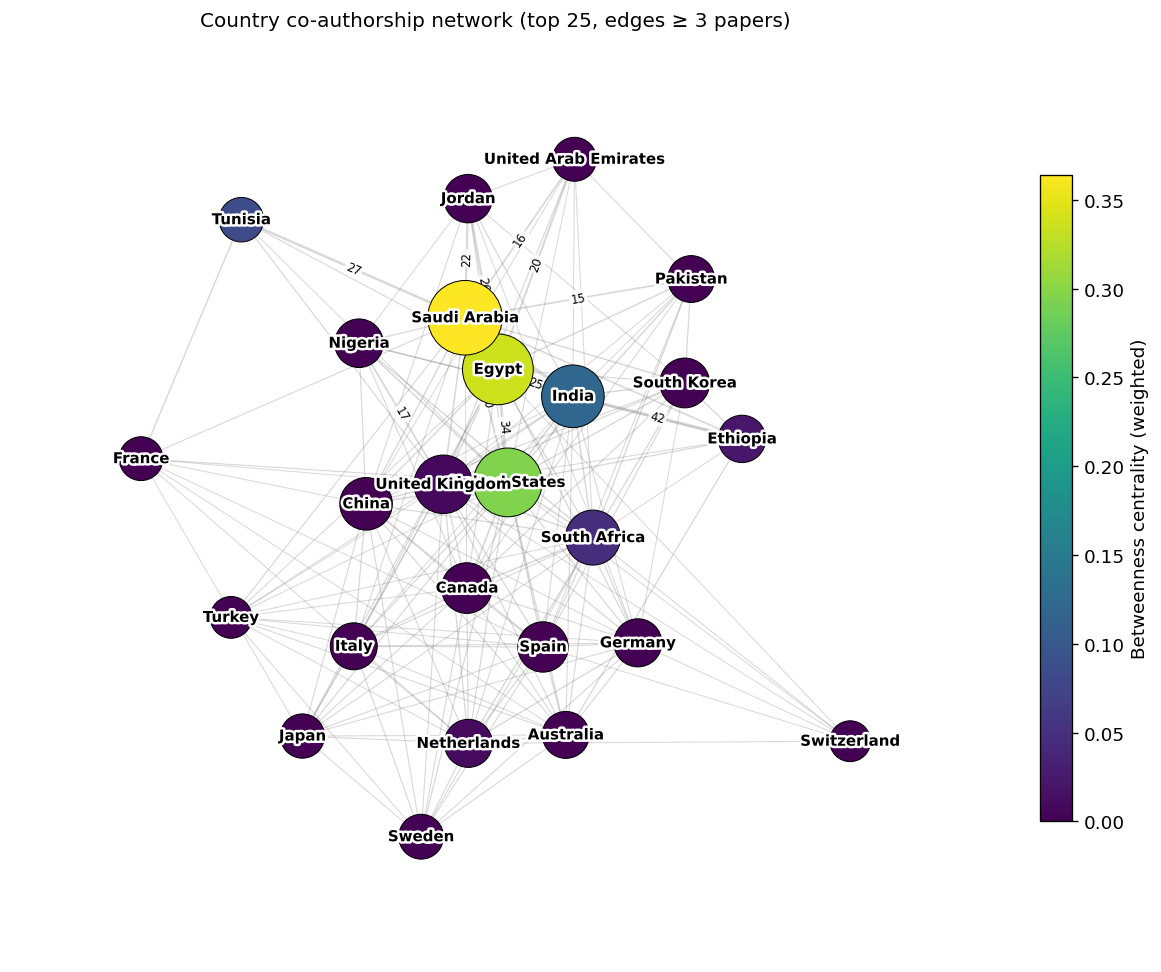

  saved fig11_country_network.png  — network
  saved table country_centrality.csv


  saved table institute_centrality.csv


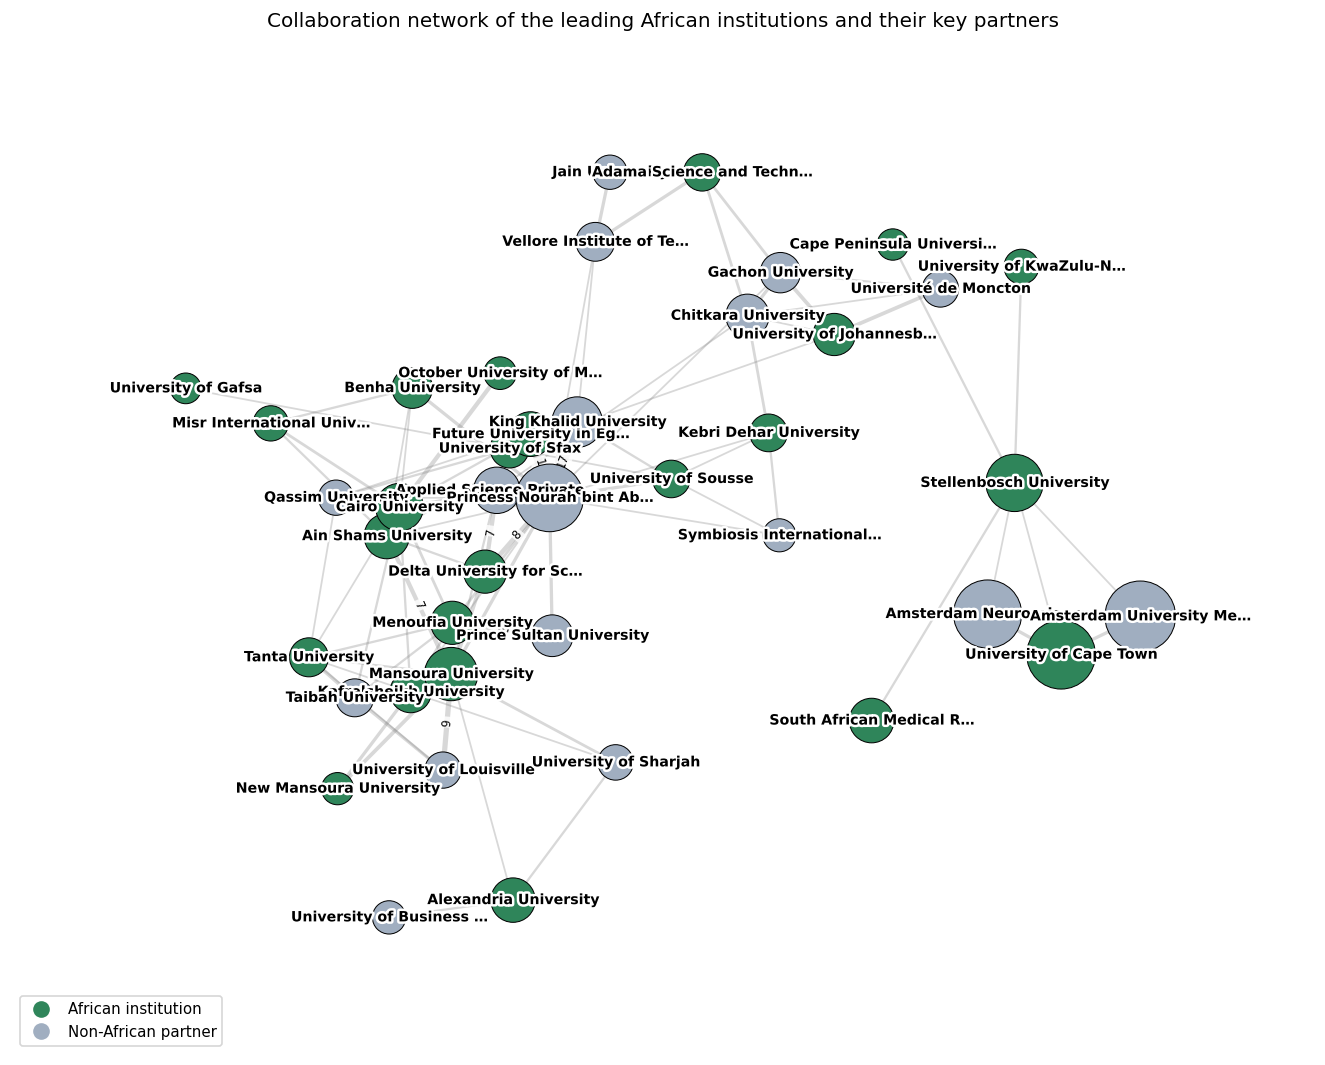

  saved fig12_institute_network.png  — African-centred institute network


In [9]:
# --------------------------------------------------------------------------- #
# 4. Collaboration networks
# --------------------------------------------------------------------------- #
def _draw_network(
    G,
    deg,
    top_n,
    min_edge,
    title,
    fname,
    shorten=False,
    label_len=20,
    k=1.8,
    figsize=(13, 10),
    n_edge_labels=15,
    font_size=9,
):
    top_nodes = deg.head(top_n).index.tolist()
    H = G.subgraph(top_nodes).copy()
    weak = [(u, v) for u, v, d in H.edges(data=True) if d["weight"] < min_edge]
    H.remove_edges_from(weak)
    H.remove_nodes_from([n for n in list(H.nodes) if H.degree(n) == 0])
    if H.number_of_nodes() == 0:
        return {}
    for u, v, d in H.edges(data=True):
        d["distance"] = 1.0 / d["weight"]
    bet = nx.betweenness_centrality(H, weight="distance")
    node_colors = [bet[n] for n in H.nodes()]
    node_sizes = [400 + 1600 * (deg[n] / deg.max()) for n in H.nodes()]
    ew = np.array([d["weight"] for _, _, d in H.edges(data=True)])
    widths = 0.5 + 5.0 * (ew / ew.max()) if len(ew) else []

    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.spring_layout(H, seed=42, weight="weight", k=k, iterations=200)
    nodes = nx.draw_networkx_nodes(
        H,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=plt.cm.viridis,
        ax=ax,
        edgecolors="black",
        linewidths=0.6,
    )
    nx.draw_networkx_edges(H, pos, width=widths, alpha=0.30, edge_color="grey", ax=ax)
    label_map = {
        n: (n[: label_len - 1] + "…" if shorten and len(n) > label_len else n)
        for n in H.nodes()
    }
    labels = nx.draw_networkx_labels(
        H, pos, labels=label_map, font_size=font_size, font_weight="bold", ax=ax
    )
    for t in labels.values():
        t.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])
    strong = sorted(H.edges(data=True), key=lambda e: -e[2]["weight"])[:n_edge_labels]
    nx.draw_networkx_edge_labels(
        H,
        pos,
        edge_labels={(u, v): d["weight"] for u, v, d in strong},
        font_size=7,
        ax=ax,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8),
    )
    cbar = plt.colorbar(nodes, ax=ax, shrink=0.7)
    cbar.set_label("Betweenness centrality (weighted)")
    ax.set_title(title)
    ax.set_axis_off()
    ax.margins(0.12)
    save_fig(fig, fname, "network")
    return bet


def analysis_networks(df):
    print("\n[4] Collaboration networks")
    # Country graph
    edges = Counter()
    for s in df["country_set"]:
        cs = sorted(s)
        for a, b in combinations(cs, 2):
            edges[(a, b)] += 1
    G = nx.Graph()
    for (a, b), n in edges.items():
        G.add_edge(a, b, weight=n)

    deg = pd.Series(dict(G.degree(weight="weight"))).sort_values(ascending=False)
    _draw_network(
        G,
        deg,
        top_n=25,
        min_edge=3,
        title="Country co-authorship network (top 25, edges ≥ 3 papers)",
        fname="fig11_country_network",
    )

    for u, v, d in G.edges(data=True):
        d["distance"] = 1.0 / d["weight"]
    centrality = pd.DataFrame(
        {
            "weighted_degree": pd.Series(dict(G.degree(weight="weight"))),
            "betweenness": pd.Series(nx.betweenness_centrality(G, weight="distance")),
            "eigenvector": pd.Series(
                nx.eigenvector_centrality(G, weight="weight", max_iter=2000)
            ),
        }
    ).sort_values("betweenness", ascending=False)
    save_table(centrality.round(4), "country_centrality")
    STATS["country_centrality_top15"] = (
        centrality.head(15)
        .round(3)
        .reset_index()
        .rename(columns={"index": "country"})
        .to_dict(orient="records")
    )

    # South-South vs North-South edge mass
    def classify_pair(a, b):
        aa, bb = is_african(a), is_african(b)
        if aa and bb:
            return "South-South"
        if aa or bb:
            return "North-South"
        return "North-North"

    pair_mass = Counter()
    for (a, b), n in edges.items():
        pair_mass[classify_pair(a, b)] += n
    STATS["collab_pair_mass"] = dict(pair_mass)

    # Institute graph
    inst_edges = Counter()
    for orgs in df["org_list"]:
        for a, b in combinations(sorted(set(orgs)), 2):
            inst_edges[(a, b)] += 1
    GI = nx.Graph()
    for (a, b), n in inst_edges.items():
        GI.add_edge(a, b, weight=n)
    inst_deg = pd.Series(dict(GI.degree(weight="weight"))).sort_values(ascending=False)
    STATS["n_institutes"] = int(GI.number_of_nodes())
    STATS["n_institute_edges"] = int(GI.number_of_edges())

    for u, v, d in GI.edges(data=True):
        d["distance"] = 1.0 / d["weight"]
    inst_centrality = pd.DataFrame(
        {
            "weighted_degree": pd.Series(dict(GI.degree(weight="weight"))),
            "betweenness": pd.Series(nx.betweenness_centrality(GI, weight="distance")),
        }
    ).sort_values("betweenness", ascending=False)
    save_table(inst_centrality.round(4), "institute_centrality")
    STATS["institute_centrality_top10"] = (
        inst_centrality.head(10)
        .round(3)
        .reset_index()
        .rename(columns={"index": "institute"})
        .to_dict(orient="records")
    )

    # African-centred institute network: the top African institutions (by paper
    # count) and the partners they most strongly collaborate with. Drawing the
    # figure around African hubs keeps it consistent with the paper's framing
    # and legible (long European-consortium clusters are excluded).
    inst_country = country_of_institution_map(df)

    def org_is_african(o):
        c = inst_country.get(o)
        return (c is not None and is_african(c)) or any(
            ac in o for ac in AFRICAN_COUNTRIES
        )

    top_af_orgs = [o for o in inst_deg.index if org_is_african(o)][:18]
    keep = set(top_af_orgs)
    # add each African hub's two strongest partners (any country)
    for o in top_af_orgs:
        nbrs = sorted(GI[o].items(), key=lambda kv: -kv[1]["weight"])[:2]
        keep.update(p for p, _ in nbrs)
    HA = GI.subgraph(keep).copy()
    weak = [(u, v) for u, v, d in HA.edges(data=True) if d["weight"] < 2]
    HA.remove_edges_from(weak)
    HA.remove_nodes_from([nd for nd in list(HA.nodes) if HA.degree(nd) == 0])

    pos = nx.spring_layout(HA, seed=42, weight="weight", k=2.6, iterations=200)
    deg_a = dict(GI.degree(weight="weight"))
    node_sizes = [
        300 + 1500 * (deg_a[nd] / max(deg_a[n2] for n2 in HA.nodes()))
        for nd in HA.nodes()
    ]
    node_colors = ["#2f855a" if org_is_african(nd) else "#a0aec0" for nd in HA.nodes()]
    ew = np.array([d["weight"] for _, _, d in HA.edges(data=True)])
    widths = 0.5 + 5.0 * (ew / ew.max()) if len(ew) else []
    fig, ax = plt.subplots(figsize=(14, 11))
    nx.draw_networkx_nodes(
        HA,
        pos,
        node_size=node_sizes,
        node_color=node_colors,
        ax=ax,
        edgecolors="black",
        linewidths=0.6,
    )
    nx.draw_networkx_edges(HA, pos, width=widths, alpha=0.30, edge_color="grey", ax=ax)
    label_map = {nd: (nd[:23] + "…" if len(nd) > 24 else nd) for nd in HA.nodes()}
    labels = nx.draw_networkx_labels(
        HA, pos, labels=label_map, font_size=8.5, font_weight="bold", ax=ax
    )
    for t in labels.values():
        t.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])
    strong = sorted(HA.edges(data=True), key=lambda e: -e[2]["weight"])[:12]
    nx.draw_networkx_edge_labels(
        HA,
        pos,
        edge_labels={(u, v): d["weight"] for u, v, d in strong},
        font_size=7,
        ax=ax,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8),
    )
    from matplotlib.lines import Line2D

    ax.legend(
        handles=[
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="#2f855a",
                markersize=11,
                label="African institution",
            ),
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor="#a0aec0",
                markersize=11,
                label="Non-African partner",
            ),
        ],
        loc="lower left",
        fontsize=9,
        frameon=True,
    )
    ax.set_title(
        "Collaboration network of the leading African institutions and their key partners"
    )
    ax.set_axis_off()
    ax.margins(0.12)
    save_fig(fig, "fig12_institute_network", "African-centred institute network")


analysis_networks(df)

## 5. Authorship power dynamics (author→country via raw affiliations)


[5] Authorship position (via raw author affiliations)


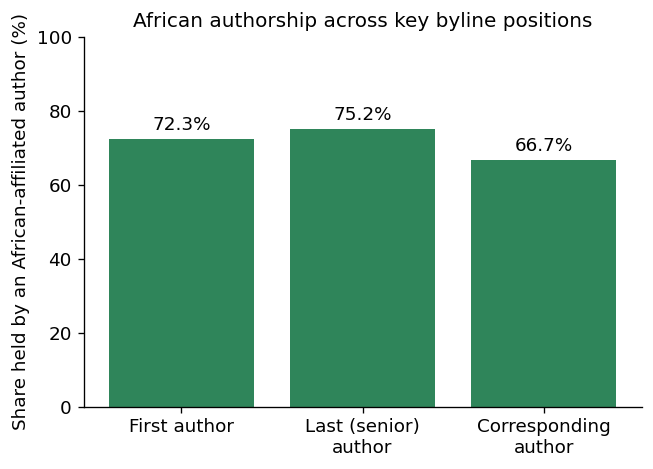

  saved fig13_authorship_position.png  — authorship position


In [10]:
# Country-name hints for non-African affiliations (used to classify a byline
# position as confidently NON-African when the raw affiliation names one of
# these countries but no African country).
NON_AFRICAN_HINTS = [
    "USA",
    "United States",
    "U.S.A",
    "UK",
    "United Kingdom",
    "England",
    "Scotland",
    "Saudi Arabia",
    "India",
    "China",
    "France",
    "Germany",
    "Canada",
    "Australia",
    "Japan",
    "South Korea",
    "Korea",
    "Pakistan",
    "Jordan",
    "Spain",
    "Italy",
    "Netherlands",
    "Sweden",
    "Belgium",
    "Switzerland",
    "Brazil",
    "United Arab Emirates",
    "Emirates",
    "Qatar",
    "Malaysia",
    "Singapore",
    "Turkey",
    "Türkiye",
    "Iran",
    "Iraq",
    "Kuwait",
    "Oman",
    "Bahrain",
    "Lebanon",
    "Russia",
    "Poland",
    "Portugal",
    "Greece",
    "Austria",
    "Norway",
    "Denmark",
    "Finland",
    "Ireland",
    "New Zealand",
    "Mexico",
    "Indonesia",
    "Thailand",
    "Vietnam",
    "Bangladesh",
    "Hong Kong",
    "Taiwan",
    "Israel",
    "Czech",
]


def parse_raw_affiliations(raw_str):
    """Parse the `Authors (Raw Affiliation)` field, which preserves author order
    and the full institutional address INCLUDING the country for each author.
    Returns a list of (author_name, affiliation_text)."""
    if pd.isna(raw_str):
        return []
    out = []
    for m in re.finditer(r"([^()]+?)\s*\(([^()]*)\)", str(raw_str)):
        name = m.group(1).strip().lstrip(";").strip()
        out.append((name, m.group(2)))
    return out


def classify_affiliation(aff_text):
    """Return 'african', 'non_african', or 'unknown' for an affiliation string."""
    has_af = any(
        re.search(r"\b" + re.escape(c) + r"\b", aff_text) for c in AFRICAN_COUNTRIES
    )
    if has_af:
        return "african"
    if any(h in aff_text for h in NON_AFRICAN_HINTS):
        return "non_african"
    return "unknown"


def analysis_authorship_position(df):
    print("\n[5] Authorship position (via raw author affiliations)")
    # Use the raw affiliation field: 99.9% coverage, author-level granularity,
    # AND explicit country names — the standardized-org country list cannot be
    # mapped to authors by position (see project notes).
    counts = {"first": Counter(), "last": Counter()}
    for raw in df["Authors (Raw Affiliation)"]:
        parsed = parse_raw_affiliations(raw)
        if not parsed:
            continue
        counts["first"][classify_affiliation(parsed[0][1])] += 1
        counts["last"][classify_affiliation(parsed[-1][1])] += 1

    def african_share(c):
        resolved = c["african"] + c["non_african"]
        return (round(c["african"] / resolved, 3) if resolved else None), resolved

    fa_share, fa_n = african_share(counts["first"])
    la_share, la_n = african_share(counts["last"])
    STATS["first_author_african_share"] = fa_share
    STATS["last_author_african_share"] = la_share
    STATS["first_author_resolved_n"] = int(fa_n)
    STATS["last_author_resolved_n"] = int(la_n)

    # Corresponding-author African share via the standardized field where present.
    inst_country = country_of_institution_map(df)

    def corresp_african(v):
        if pd.isna(v):
            return None
        s = str(v)
        if any(re.search(r"\b" + re.escape(c) + r"\b", s) for c in AFRICAN_COUNTRIES):
            return True
        # institution-name match against the standardized org->country map
        for org, ctry in inst_country.items():
            if org in s:
                return is_african(ctry)
        if any(h in s for h in NON_AFRICAN_HINTS):
            return False
        return None

    corr = df["Corresponding Authors"].apply(corresp_african)
    corr_known = corr.notna()
    STATS["corresponding_author_african_share"] = (
        round(float(corr[corr_known].mean()), 3) if corr_known.any() else None
    )
    STATS["corresponding_author_resolved_n"] = int(corr_known.sum())

    fig, ax = plt.subplots(figsize=(6, 4))
    labels = ["First author", "Last (senior)\nauthor", "Corresponding\nauthor"]
    vals = [
        STATS["first_author_african_share"],
        STATS["last_author_african_share"],
        STATS["corresponding_author_african_share"],
    ]
    bars = ax.bar(labels, [v * 100 for v in vals], color="#2f855a")
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_ylabel("Share held by an African-affiliated author (%)")
    ax.set_ylim(0, 100)
    ax.set_title("African authorship across key byline positions")
    save_fig(fig, "fig13_authorship_position", "authorship position")


analysis_authorship_position(df)

## 6. Research portfolio (topics / fields / clinical domains)


[6] Research portfolio


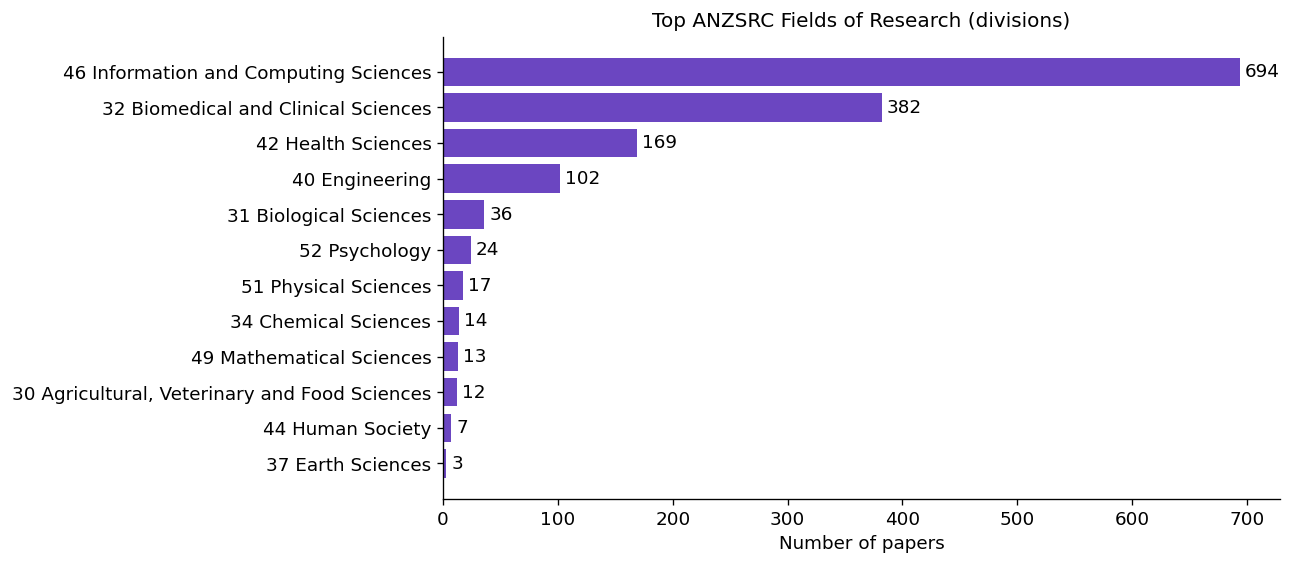

  saved fig14_fields_of_research.png  — fields of research
  saved table rcdc_categories.csv


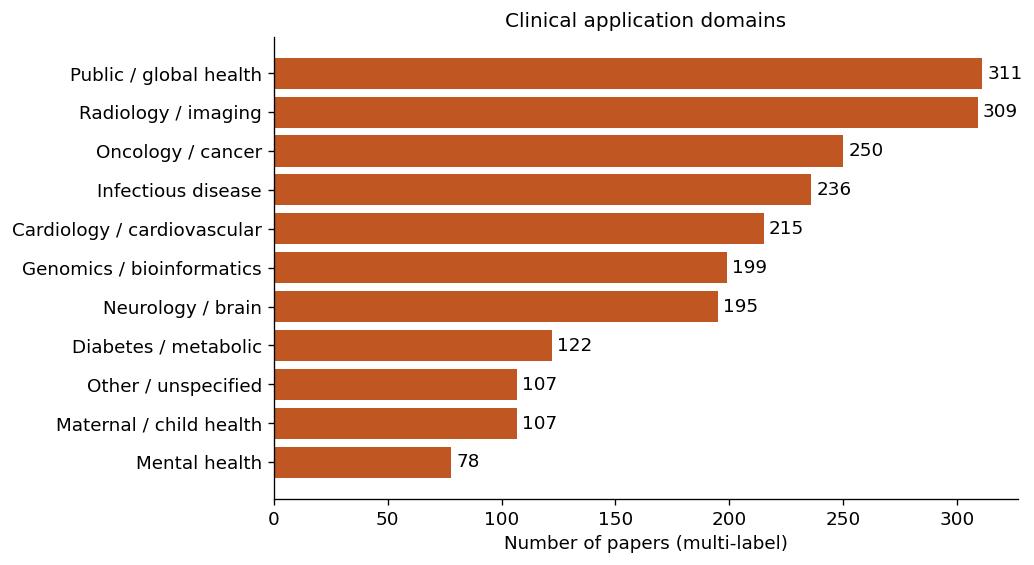

  saved fig15_clinical_domains.png  — clinical domains


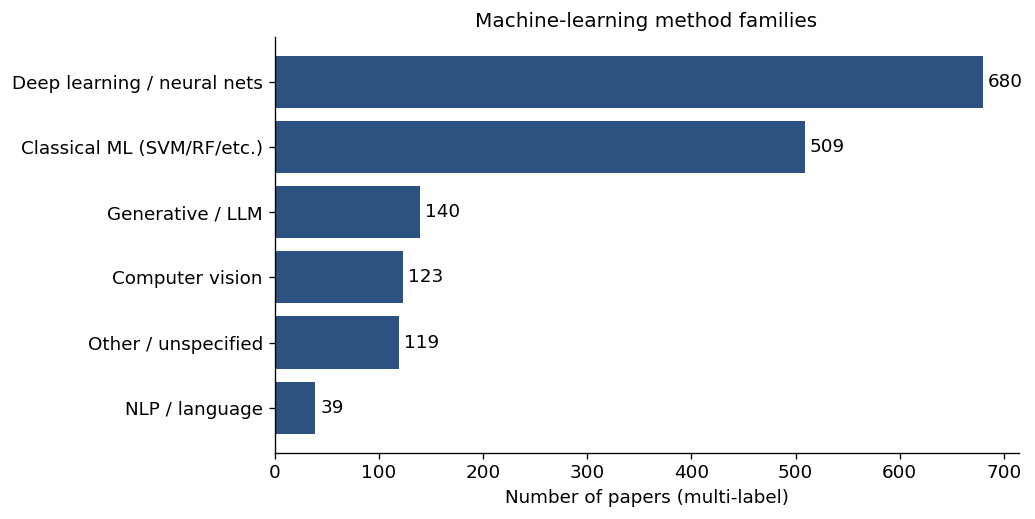

  saved fig16_ml_methods.png  — ML methods


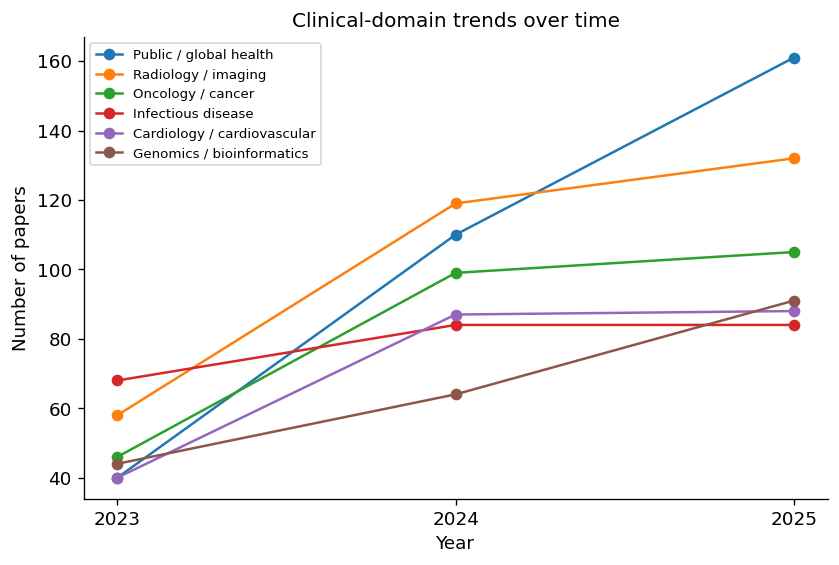

  saved fig17_domain_trends.png  — domain trends


In [11]:
# --------------------------------------------------------------------------- #
# 6. Research portfolio (topics / fields / clinical domains)
# --------------------------------------------------------------------------- #
CLINICAL_DOMAINS = {
    "Oncology / cancer": [
        "cancer",
        "tumor",
        "tumour",
        "oncolog",
        "carcinoma",
        "melanoma",
        "leukemia",
        "leukaemia",
        "lymphoma",
        "mammogra",
        "breast cancer",
    ],
    "Infectious disease": [
        "covid",
        "sars-cov",
        "tuberculosis",
        "malaria",
        "hiv",
        "hepatitis",
        "infectious",
        "pneumonia",
        "dengue",
        "sepsis",
        "viral",
        "bacterial",
        "antimicrobial",
        "epidemic",
        "pandemic",
    ],
    "Cardiology / cardiovascular": [
        "cardiac",
        "cardio",
        "heart",
        "ecg",
        "arrhythm",
        "myocard",
        "coronary",
        "hypertension",
        "blood pressure",
    ],
    "Neurology / brain": [
        "brain",
        "neuro",
        "alzheimer",
        "epilep",
        "seizure",
        "stroke",
        "eeg",
        "mri",
        "parkinson",
        "dementia",
        "autism",
    ],
    "Diabetes / metabolic": ["diabet", "glucose", "insulin", "metabolic", "obesity"],
    "Radiology / imaging": [
        "radiolog",
        "x-ray",
        "ct scan",
        "ultrasound",
        "imaging",
        "segmentation",
        "retina",
        "fundus",
        "diabetic retinopathy",
    ],
    "Maternal / child health": [
        "maternal",
        "pregnan",
        "neonat",
        "infant",
        "fetal",
        "foetal",
        "child health",
        "pediatric",
        "paediatric",
        "birth",
    ],
    "Mental health": [
        "mental health",
        "depress",
        "anxiety",
        "psychiatr",
        "schizophrenia",
        "stress detection",
    ],
    "Genomics / bioinformatics": [
        "genom",
        "gene expression",
        "dna",
        "rna",
        "sequenc",
        "bioinformatic",
        "proteom",
        "microarray",
    ],
    "Public / global health": [
        "public health",
        "global health",
        "surveillance",
        "health system",
        "epidemiolog",
        "disease outbreak",
    ],
}

ML_METHODS = {
    "Deep learning / neural nets": [
        "deep learning",
        "neural network",
        "cnn",
        "convolutional",
        "rnn",
        "lstm",
        "transformer",
        "deep neural",
    ],
    "Classical ML (SVM/RF/etc.)": [
        "support vector",
        "random forest",
        "decision tree",
        "xgboost",
        "gradient boost",
        "logistic regression",
        "naive bayes",
        "k-nearest",
        "knn",
        "ensemble",
    ],
    "Computer vision": [
        "computer vision",
        "image classification",
        "object detection",
        "image segmentation",
        "medical imaging",
    ],
    "NLP / language": [
        "natural language",
        "nlp",
        "text mining",
        "language model",
        "named entity",
        "sentiment",
    ],
    "Generative / LLM": [
        "generative adversarial",
        "gan",
        "large language model",
        "llm",
        "diffusion model",
        "chatgpt",
        "gpt-",
    ],
}


def _keyword_tag(text, taxonomy):
    text = text.lower()
    hits = []
    for label, kws in taxonomy.items():
        if any(kw in text for kw in kws):
            hits.append(label)
    return hits


def analysis_portfolio(df):
    print("\n[6] Research portfolio")
    # 6a. ANZSRC Fields of Research (top-level 2-digit divisions)
    fields = Counter()
    for v in df["Fields of Research (ANZSRC 2020)"]:
        for f in split_multi(v):
            # keep only 2-digit divisions like "32 Biomedical and Clinical Sciences"
            m = re.match(r"^(\d{2})\s+(.*)$", f)
            if m:
                fields[f"{m.group(1)} {m.group(2)}"] += 1
    fields_s = pd.Series(fields).sort_values(ascending=False).head(12)
    STATS["top_fields_of_research"] = {k: int(v) for k, v in fields_s.head(10).items()}
    fig, ax = plt.subplots(figsize=(9, 5))
    bars = ax.barh(
        [x[:50] for x in fields_s.index[::-1]], fields_s.values[::-1], color="#6b46c1"
    )
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of papers")
    ax.set_title("Top ANZSRC Fields of Research (divisions)")
    save_fig(fig, "fig14_fields_of_research", "fields of research")

    # 6b. RCDC categories
    rcdc = Counter()
    for v in df["RCDC Categories"]:
        rcdc.update(split_multi(v))
    rcdc_s = pd.Series(rcdc).sort_values(ascending=False).head(20)
    STATS["top_rcdc_categories"] = {k: int(v) for k, v in rcdc_s.head(15).items()}
    save_table(rcdc_s.rename("papers").to_frame(), "rcdc_categories")

    # 6c. Clinical domain tagging from title+abstract
    text_series = df["Title"].fillna("") + ". " + df["Abstract"].fillna("")
    domain_counts = Counter()
    domain_by_paper = []
    for t in text_series:
        hits = _keyword_tag(t, CLINICAL_DOMAINS)
        domain_by_paper.append(hits)
        domain_counts.update(hits or ["Other / unspecified"])
    df["clinical_domains"] = domain_by_paper
    dom_s = pd.Series(domain_counts).sort_values(ascending=False)
    STATS["clinical_domains"] = {k: int(v) for k, v in dom_s.items()}
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.barh(dom_s.index[::-1], dom_s.values[::-1], color="#c05621")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of papers (multi-label)")
    ax.set_title("Clinical application domains")
    save_fig(fig, "fig15_clinical_domains", "clinical domains")

    # 6d. ML method tagging
    method_counts = Counter()
    for t in text_series:
        hits = _keyword_tag(t, ML_METHODS)
        method_counts.update(hits or ["Other / unspecified"])
    meth_s = pd.Series(method_counts).sort_values(ascending=False)
    STATS["ml_methods"] = {k: int(v) for k, v in meth_s.items()}
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.barh(meth_s.index[::-1], meth_s.values[::-1], color="#2c5282")
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of papers (multi-label)")
    ax.set_title("Machine-learning method families")
    save_fig(fig, "fig16_ml_methods", "ML methods")

    # 6e. Domain x year trend (top 6 domains)
    top_domains = [d for d in dom_s.head(6).index if d != "Other / unspecified"]
    years = sorted(df["PubYear"].dropna().unique().tolist())
    fig, ax = plt.subplots(figsize=(8, 5))
    for d in top_domains:
        series = []
        for y in years:
            sub = df[df["PubYear"] == y]
            series.append(sum(d in hits for hits in sub["clinical_domains"]))
        ax.plot([int(y) for y in years], series, marker="o", label=d)
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of papers")
    ax.set_xticks([int(y) for y in years])
    ax.set_title("Clinical-domain trends over time")
    ax.legend(fontsize=8)
    save_fig(fig, "fig17_domain_trends", "domain trends")
    return df


df = analysis_portfolio(df)

## 7. Dataset landscape & data sovereignty (LLM-extracted fields)


[7] Dataset landscape
  saved table named_datasets.csv


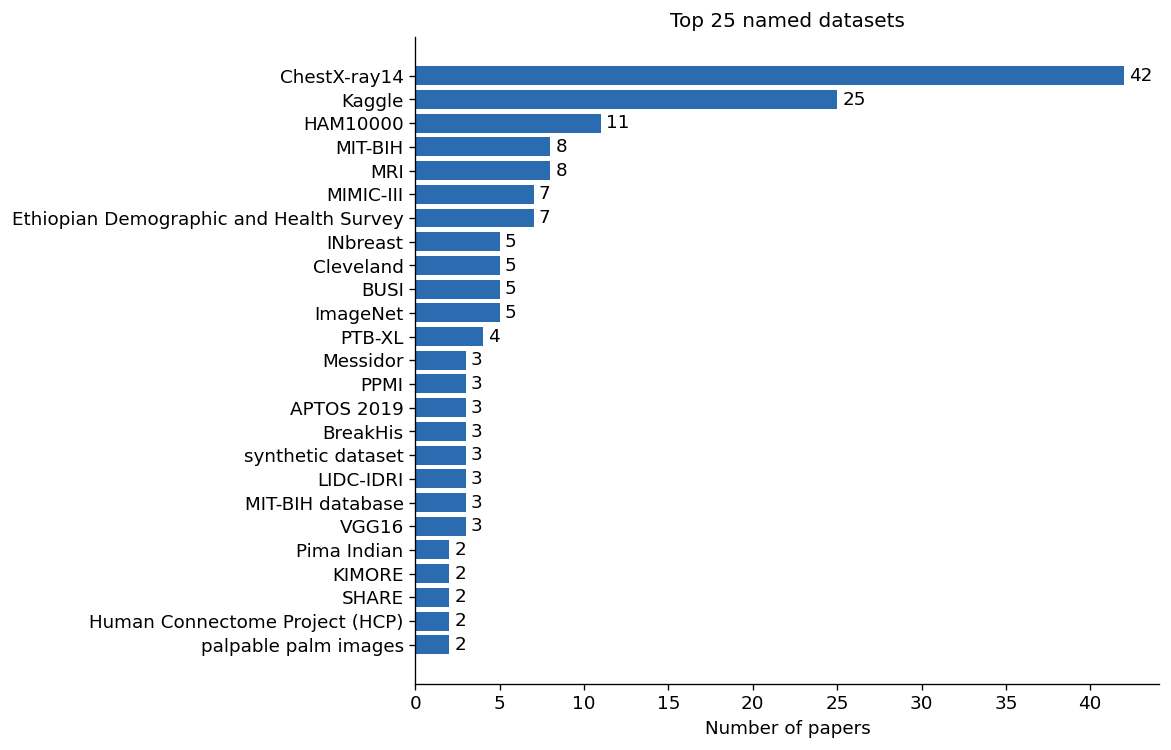

  saved fig18_named_datasets.png  — named datasets


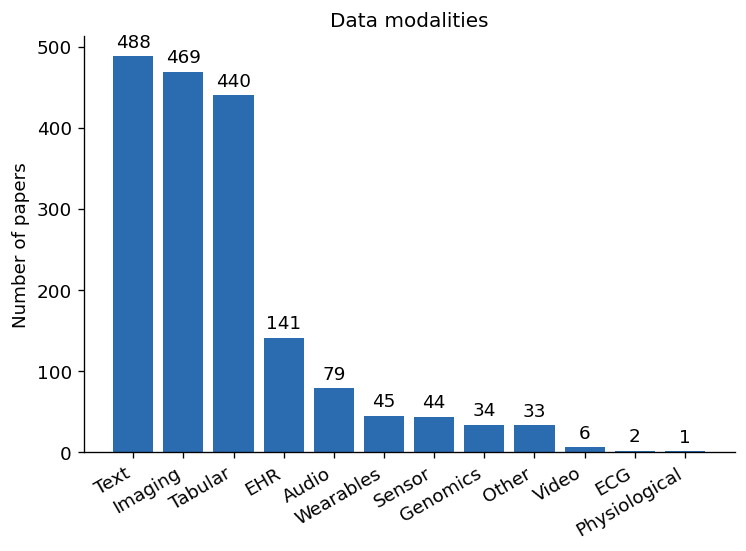

  saved fig19_data_modalities.png  — data modalities


In [12]:
# --------------------------------------------------------------------------- #
# 7. Dataset landscape & data sovereignty (LLM-extracted fields)
# --------------------------------------------------------------------------- #
def analysis_datasets(df):
    print("\n[7] Dataset landscape")
    if "datasets_llm" not in df.columns:
        print("  (no LLM dataset fields; skipping)")
        return

    ds = Counter()
    for v in df["datasets_llm"].fillna(""):
        ds.update(split_multi(v))
    ds_s = pd.Series(ds).sort_values(ascending=False).head(25)
    STATS["top_named_datasets"] = {k: int(v) for k, v in ds_s.head(20).items()}
    no_named = df["datasets_llm"].fillna("").str.strip().eq("").mean()
    STATS["share_no_named_dataset"] = round(float(no_named), 3)
    save_table(ds_s.rename("papers").to_frame(), "named_datasets")
    fig, ax = plt.subplots(figsize=(8, 7))
    bars = ax.barh(
        [x[:40] for x in ds_s.index[::-1]], ds_s.values[::-1], color="#2b6cb0"
    )
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of papers")
    ax.set_title("Top 25 named datasets")
    save_fig(fig, "fig18_named_datasets", "named datasets")

    # Patient origin countries
    pc = Counter()
    for v in df["patient_origin_countries_llm"].fillna(""):
        pc.update(split_multi(v))
    total_pc = sum(pc.values())
    african_pc = sum(n for c, n in pc.items() if is_african(c))
    STATS["patient_origin_african_share"] = (
        round(african_pc / total_pc, 3) if total_pc else None
    )
    STATS["top_patient_origin_countries"] = {
        k: int(v)
        for k, v in pd.Series(pc).sort_values(ascending=False).head(15).items()
    }
    share_with_origin = (
        df["patient_origin_countries_llm"].fillna("").str.strip().ne("").mean()
    )
    STATS["share_papers_with_patient_origin"] = round(float(share_with_origin), 3)

    # Data modality
    mod = Counter()
    for v in df["data_modality_llm"].fillna(""):
        mod.update(split_multi(v))
    mod_s = pd.Series(mod).sort_values(ascending=False)
    STATS["data_modalities"] = {k: int(v) for k, v in mod_s.items()}
    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(mod_s.index, mod_s.values, color="#2b6cb0")
    ax.bar_label(bars, padding=3)
    ax.set_ylabel("Number of papers")
    ax.set_title("Data modalities")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    save_fig(fig, "fig19_data_modalities", "data modalities")


analysis_datasets(df)

## 8. Funding landscape


[8] Funding landscape
  saved table funders.csv


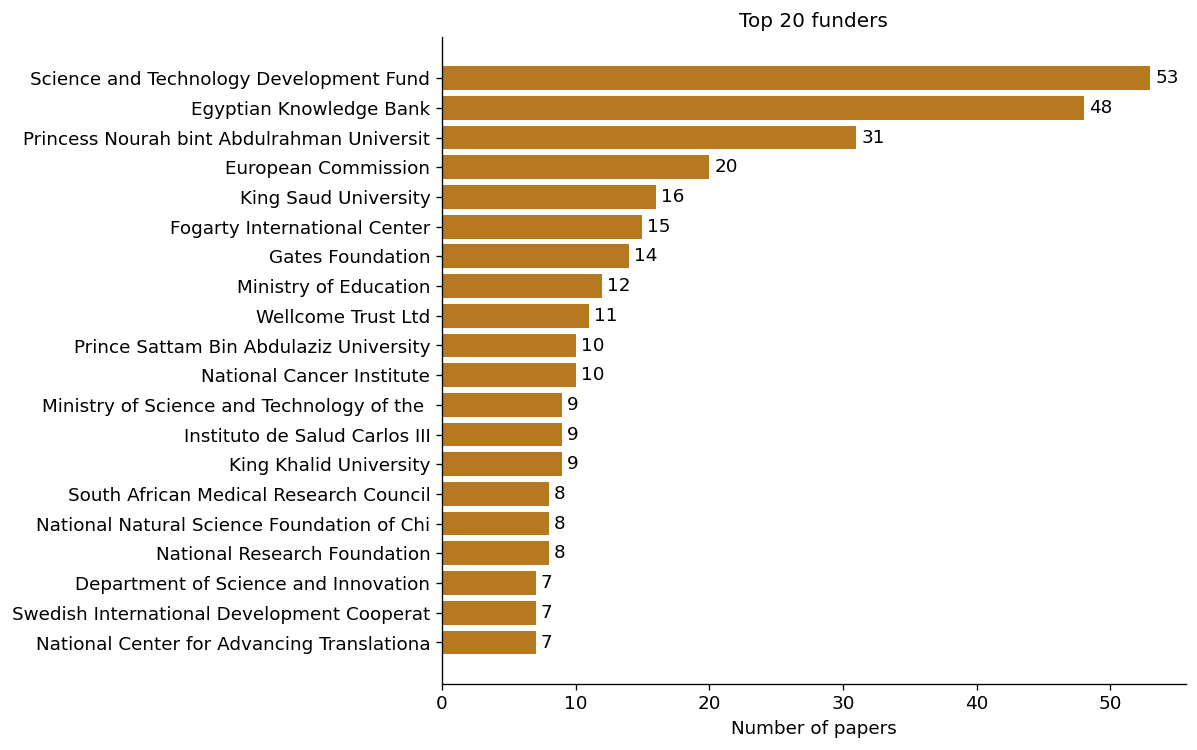

  saved fig20_top_funders.png  — top funders
  saved table funder_countries.csv


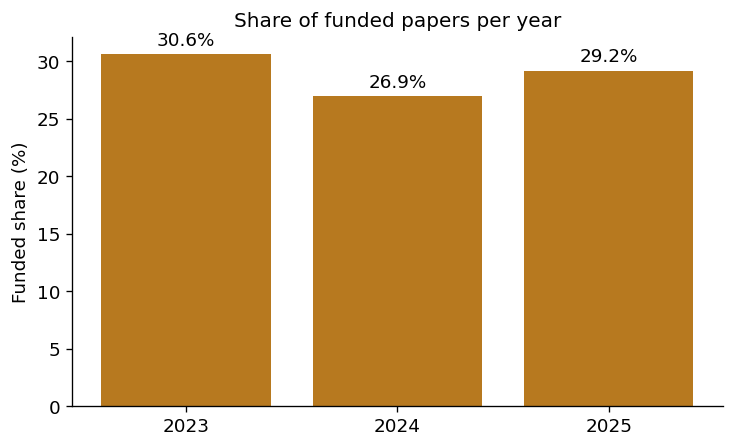

  saved fig21_funded_per_year.png  — funded share per year


In [13]:
# --------------------------------------------------------------------------- #
# 8. Funding landscape
# --------------------------------------------------------------------------- #
def analysis_funding(df):
    print("\n[8] Funding landscape")
    has_funder = df["Funder"].fillna("").str.strip().ne("")
    STATS["funded_share"] = round(float(has_funder.mean()), 3)
    STATS["unfunded_share"] = round(float((~has_funder).mean()), 3)

    funder = Counter()
    for v in df["Funder"]:
        funder.update(split_multi(v))
    funder_s = pd.Series(funder).sort_values(ascending=False).head(20)
    STATS["top_funders"] = {k: int(v) for k, v in funder_s.head(12).items()}
    save_table(funder_s.rename("papers").to_frame(), "funders")
    fig, ax = plt.subplots(figsize=(8, 7))
    bars = ax.barh(
        [x[:42] for x in funder_s.index[::-1]], funder_s.values[::-1], color="#b7791f"
    )
    ax.bar_label(bars, padding=3)
    ax.set_xlabel("Number of papers")
    ax.set_title("Top 20 funders")
    save_fig(fig, "fig20_top_funders", "top funders")

    fc = Counter()
    for v in df["Funder Country"]:
        fc.update(split_multi(v))
    fc_s = pd.Series(fc).sort_values(ascending=False).head(20)
    total_fc = sum(fc.values())
    STATS["top_funder_countries"] = {k: int(v) for k, v in fc_s.head(15).items()}
    STATS["african_funder_country_share"] = (
        round(sum(n for c, n in fc.items() if is_african(c)) / total_fc, 3)
        if total_fc
        else None
    )
    save_table(fc_s.rename("papers").to_frame(), "funder_countries")

    # Funder-country -> recipient-country flow
    country_flow = Counter()
    for _, r in df.iterrows():
        fcs = set(split_multi(r["Funder Country"]))
        rcs = r["country_set"]
        for f_ in fcs:
            for rc in rcs:
                country_flow[(f_, rc)] += 1
    top_flows = sorted(country_flow.items(), key=lambda x: -x[1])[:15]
    STATS["top_funding_flows"] = [
        {"funder_country": a, "recipient_country": b, "papers": int(n)}
        for (a, b), n in top_flows
    ]
    # share of within-country funding
    within = sum(n for (a, b), n in country_flow.items() if a == b)
    total_flow = sum(country_flow.values())
    STATS["within_country_funding_share"] = (
        round(within / total_flow, 3) if total_flow else None
    )

    # funded-share-per-year
    fig, ax = plt.subplots(figsize=(7, 4))
    fy = df.groupby(df["PubYear"].astype(int)).apply(
        lambda g: has_funder.loc[g.index].mean()
    )
    bars = ax.bar([str(y) for y in fy.index], (fy.values * 100), color="#b7791f")
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_ylabel("Funded share (%)")
    ax.set_title("Share of funded papers per year")
    save_fig(fig, "fig21_funded_per_year", "funded share per year")


analysis_funding(df)

## 9. Citation impact


[9] Citation impact
  saved table most_cited_papers.csv
  saved table citations_by_collab.csv


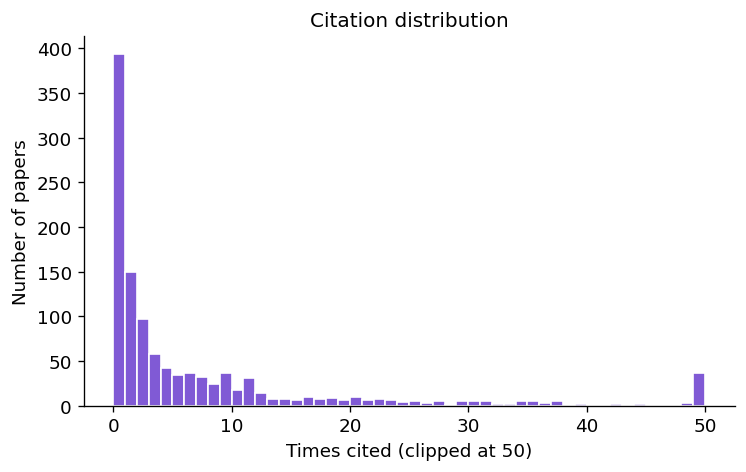

  saved fig22_citation_distribution.png  — citation distribution


In [14]:
# --------------------------------------------------------------------------- #
# 9. Citation impact
# --------------------------------------------------------------------------- #
def analysis_citations(df):
    print("\n[9] Citation impact")
    tc = df["Times cited"].fillna(0)
    STATS["citations"] = {
        "mean": round(float(tc.mean()), 2),
        "median": int(tc.median()),
        "max": int(tc.max()),
        "share_uncited": round(float((tc == 0).mean()), 3),
    }
    STATS["mean_FCR"] = (
        round(float(df["FCR"].mean()), 2) if df["FCR"].notna().any() else None
    )

    # Most-cited papers
    top_cited = df.nlargest(10, "Times cited")[
        ["Title", "PubYear", "Times cited", "Source title", "DOI"]
    ].copy()
    top_cited["Times cited"] = top_cited["Times cited"].astype(int)
    save_table(top_cited.set_index("Title"), "most_cited_papers")
    STATS["most_cited_papers"] = [
        {
            "title": str(r["Title"]),
            "year": int(r["PubYear"]),
            "citations": int(r["Times cited"]),
            "venue": str(r["Source title"]),
            "doi": (str(r["DOI"]) if pd.notna(r["DOI"]) else None),
        }
        for _, r in top_cited.iterrows()
    ]

    # Citations by collaboration type
    if "collab_type" in df.columns:
        by_collab = (
            df.groupby("collab_type")["Times cited"]
            .agg(["mean", "median", "count"])
            .round(2)
        )
        save_table(by_collab, "citations_by_collab")
        STATS["citations_by_collab"] = {
            str(k): {
                "mean": float(v["mean"]),
                "median": float(v["median"]),
                "n": int(v["count"]),
            }
            for k, v in by_collab.iterrows()
        }

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(tc.clip(upper=50), bins=50, color="#805ad5", edgecolor="white")
    ax.set_xlabel("Times cited (clipped at 50)")
    ax.set_ylabel("Number of papers")
    ax.set_title("Citation distribution")
    save_fig(fig, "fig22_citation_distribution", "citation distribution")


analysis_citations(df)

## 10. OpenAlex author seniority enrichment


[10] Author seniority (OpenAlex)
  saved table top_african_authors.csv
  saved table author_seniority_openalex.csv


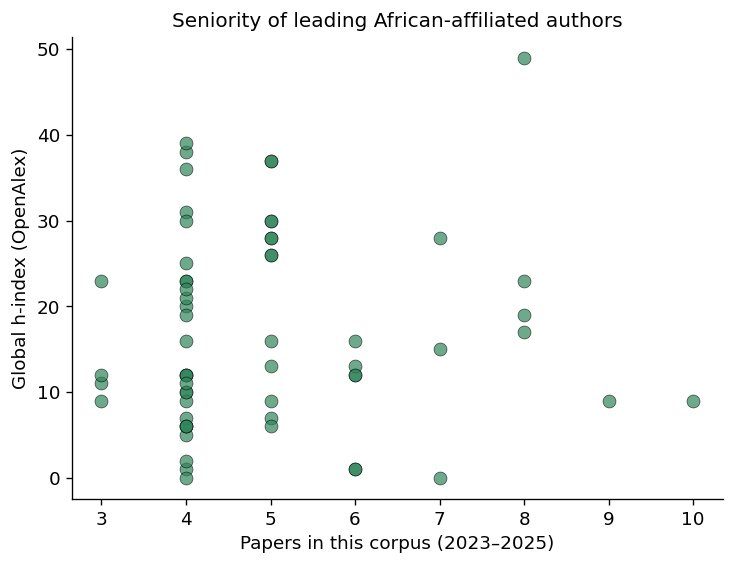

  saved fig23_author_seniority.png  — author seniority


In [15]:
# --------------------------------------------------------------------------- #
# 10. OpenAlex author seniority enrichment
# --------------------------------------------------------------------------- #
def _load_openalex_cache():
    if OPENALEX_CACHE.exists():
        return json.loads(OPENALEX_CACHE.read_text())
    return {}


def _save_openalex_cache(cache):
    OPENALEX_CACHE.write_text(json.dumps(cache, indent=0))


def analysis_authors_openalex(df):
    print("\n[10] Author seniority (OpenAlex)")
    # Identify the most frequent authors who have ≥1 African institution.
    inst_country = country_of_institution_map(df)
    author_papers = Counter()
    author_is_af = {}
    for parsed in df["affil_parsed"]:
        for name, insts in parsed:
            author_papers[name] += 1
            if name not in author_is_af:
                af = any(
                    (inst_country.get(i) and is_african(inst_country[i]))
                    or any(ac in i for ac in AFRICAN_COUNTRIES)
                    for i in insts
                )
                author_is_af[name] = af
    african_authors = [
        (a, n) for a, n in author_papers.most_common() if author_is_af.get(a)
    ]
    STATS["n_distinct_authors"] = int(len(author_papers))
    STATS["n_distinct_african_authors"] = int(
        sum(1 for a in author_is_af if author_is_af[a])
    )
    STATS["top_african_authors_by_corpus_count"] = [
        {"author": a, "papers_in_corpus": int(n)} for a, n in african_authors[:20]
    ]
    save_table(
        pd.DataFrame(african_authors, columns=["author", "papers_in_corpus"]).set_index(
            "author"
        ),
        "top_african_authors",
    )

    if not ENABLE_OPENALEX:
        print("  OpenAlex disabled — using corpus-internal productivity only.")
        return

    import requests

    AFRICAN_ISO2 = {
        "DZ",
        "AO",
        "BJ",
        "BW",
        "BF",
        "BI",
        "CV",
        "CM",
        "CF",
        "TD",
        "KM",
        "CG",
        "CD",
        "CI",
        "DJ",
        "EG",
        "GQ",
        "ER",
        "SZ",
        "ET",
        "GA",
        "GM",
        "GH",
        "GN",
        "GW",
        "KE",
        "LS",
        "LR",
        "LY",
        "MG",
        "MW",
        "ML",
        "MR",
        "MU",
        "MA",
        "MZ",
        "NA",
        "NE",
        "NG",
        "RW",
        "ST",
        "SN",
        "SC",
        "SL",
        "SO",
        "ZA",
        "SS",
        "SD",
        "TZ",
        "TG",
        "TN",
        "UG",
        "ZM",
        "ZW",
    }

    def _norm_name(s):
        """Normalise a name to a comparable token set (handles 'Surname, Given')."""
        s = re.sub(r"[^A-Za-z\s,]", " ", str(s)).lower()
        s = s.replace(",", " ")
        return {t for t in s.split() if len(t) > 1}

    def _name_matches(query, candidate):
        """True if the candidate display name plausibly matches the query name.
        Require that the candidate shares the surname and at least one more token
        with the query (guards against unrelated homonyms / wrong matches)."""
        q, c = _norm_name(query), _norm_name(candidate)
        if not q or not c:
            return False
        overlap = q & c
        return len(overlap) >= 2 or (len(q) == 1 and q <= c)

    def _extract(a):
        insts = a.get("last_known_institutions") or []
        inst0 = insts[0] if insts else {}
        return {
            "openalex_id": a.get("id"),
            "display_name": a.get("display_name"),
            "works_count": a.get("works_count"),
            "cited_by_count": a.get("cited_by_count"),
            "h_index": (a.get("summary_stats") or {}).get("h_index"),
            "i10_index": (a.get("summary_stats") or {}).get("i10_index"),
            "orcid": a.get("orcid"),
            "last_known_institution": inst0.get("display_name"),
            "country_code": inst0.get("country_code"),
        }

    cache = _load_openalex_cache()
    enriched = []
    targets = african_authors[:OPENALEX_TOP_AUTHORS]
    session = requests.Session()
    for name, corpus_n in targets:
        key = name
        if key not in cache:
            try:
                url = "https://api.openalex.org/authors"
                # pull several candidates and pick the best verified match,
                # preferring one whose last-known institution is in Africa.
                params = {"search": name, "per-page": 10, "mailto": OPENALEX_MAILTO}
                r = session.get(url, params=params, timeout=30)
                r.raise_for_status()
                results = r.json().get("results", [])
                verified = [
                    a for a in results if _name_matches(name, a.get("display_name", ""))
                ]
                african = [
                    a
                    for a in verified
                    if ((a.get("last_known_institutions") or [{}])[0] or {}).get(
                        "country_code"
                    )
                    in AFRICAN_ISO2
                ]
                chosen = african[0] if african else (verified[0] if verified else None)
                if chosen is not None:
                    rec = _extract(chosen)
                    rec["match_verified"] = True
                    rec["match_african_inst"] = bool(african)
                    cache[key] = rec
                else:
                    cache[key] = {"openalex_id": None, "match_verified": False}
                time.sleep(0.15)  # be polite
            except Exception as e:  # pragma: no cover
                print(f"    OpenAlex lookup failed for {name!r}: {e}")
                cache[key] = {"openalex_id": None, "match_verified": False}
        info = dict(cache[key])
        info["author"] = name
        info["papers_in_corpus"] = corpus_n
        enriched.append(info)
    _save_openalex_cache(cache)

    edf = pd.DataFrame(enriched)
    matched = edf[edf["openalex_id"].notna()].copy()
    if len(matched):
        matched["h_index"] = pd.to_numeric(matched["h_index"], errors="coerce")
        matched["works_count"] = pd.to_numeric(matched["works_count"], errors="coerce")
        STATS["openalex_n_matched"] = int(len(matched))
        STATS["openalex_median_h_index"] = (
            float(matched["h_index"].median())
            if matched["h_index"].notna().any()
            else None
        )
        STATS["openalex_median_works_count"] = (
            float(matched["works_count"].median())
            if matched["works_count"].notna().any()
            else None
        )
        save_table(matched.set_index("author"), "author_seniority_openalex")

        # Seniority scatter: corpus output vs global h-index
        sub = matched.dropna(subset=["h_index"])
        if len(sub):
            fig, ax = plt.subplots(figsize=(7, 5))
            ax.scatter(
                sub["papers_in_corpus"],
                sub["h_index"],
                alpha=0.7,
                s=60,
                color="#2f855a",
                edgecolors="black",
                linewidths=0.4,
            )
            ax.set_xlabel("Papers in this corpus (2023–2025)")
            ax.set_ylabel("Global h-index (OpenAlex)")
            ax.set_title("Seniority of leading African-affiliated authors")
            save_fig(fig, "fig23_author_seniority", "author seniority")


analysis_authors_openalex(df)

## Write the collected statistics

In [16]:
stats_path = FIG / "stats.json"
stats_path.write_text(json.dumps(STATS, indent=2, ensure_ascii=False))
print(f"Wrote {stats_path.relative_to(ROOT)} with {len(STATS)} top-level keys.")

Wrote figures/stats.json with 63 top-level keys.
